# Creating our own Auto Differentiation (AutoGrad) framework

In this practical exercise we will build our own, very simple, Auto-differentiation (or AutoGrad) framework.

## Coding the framework

### Step 1: Define a class for our variables

The key idea is that we will define our own class of `Variable` which is basically the same as a scalar (a number). So our class is created by passing it a `value`, and it stores this value internally.

But apart from being a placeholder for a number, we also want to keep track of the operation that created every `Variable`.

For example, if a variable $c$ is the result of the addition of two variables $a$ and $b$: $c = a + b$, then we would say that $a$ and $b$ are "parent" variables of $c$, and $c$ is their "child". The way $c$ was created was by adding these two parent variables together. A variable created directly (defined by the user, not resulting by any operation over existing variables) would have no parents.

So apart from the value of the `Variable`, we will also have to keep track of its parents, and on how each of them "contributes" to the value of the `Variable` - this is described by the local derivative associated with each of the parents, that tells us how a change in the value of each of the parent variables translates into a change in the value of the child variable.

This is important in order to implement our backwards pass. During the backwards pass each parent defines a "route" through which the gradients coming into our variable will have to flow through.

So we will define a list of `gradRoutes` that will contain the list of parent variables and their corresponding local derivatives. A `Variable` created directly (not resulting by any operation over existing variables) will have an empty `gradRoutes`.

Finally, we want each `Variable` of ours to keep track of the value of gradient of the quantity we are interested in (usually the loss) with respect to the `Variable` itself. We will create a placeholder for that as well, called `grad`. As seen in theory, this placeholder will accummulate the gradients that are backpropagated from the children of this variable when we implement the backpropagation algorithm. So we will initialise it to zero.

In [1]:
import numpy as np

In [2]:
class Variable: 
    # Simple variable. These are the leafs of our tree, they can request to have a gradient calculated, or not
    def __init__(self, value):
        self.value = value
        self.gradRoutes = [] # A variable by default has no grad Routes (was not created by anything, just defined)
        self.grad = 0.0

    def __str__(self):
        return 'Value: {self.value}'.format(self=self)

Apart from the `__init__()` function which stores the value passed to our class and initialises the `gradRoutes` and `grad` member variables, we have also overloaded the function that python uses to convert a class into a string representation: `__str__()`. This will allow us to print our class.

We cannot do much yet with this class, apart from storing values into our variables and printing them out. Let's try this out.

In [3]:
a = Variable(4.3)
b = Variable(5.2)
print(a)
print(b)

Value: 4.3
Value: 5.2


### Step 2: Define operations over our variables

The next step would be to implement operations on our variables. Let's first define the operations for addition and multiplication.

These will be functions that take two `variables` as input and produce a new (child) `variable` with a value equal to the sum or the product of the two inputs. Apart from the forward pass though, we should keep track of how this new `variable` was created: the two parent `variables`, and their corresponding local derivatives. In our code we put these two things in a tuple and save them in the list of `gradRoutes`.

In [4]:
def vAdd(A: Variable, B: Variable): 
    # Addition
    result = Variable(A.value + B.value) # Create a new Variable to store the result, and pass it the value = a + b

    # Keep track of the parent variables, and of the local derivative associated with each one
    result.gradRoutes.append((A, 1)) # dresult / dA = 1
    result.gradRoutes.append((B, 1)) # dresult / dB = 1

    return result

def vMul(A: Variable, B: Variable): 
    # Multiplication
    result = Variable(A.value * B.value) # Create a new Variable to store the result, and pass it the value = a * b

    # Keep track of the parent variables, and of the local derivative associated with each one
    result.gradRoutes.append((A, B.value)) # dresult / dA = B
    result.gradRoutes.append((B, A.value)) # dresult / dB = A

    return result

So for example to calculate $d = (a + b) * c$ we first need to calculate $(a + b)$ and then mutiply the result with $c$

In [5]:
a = Variable(2) # a = 2
b = Variable(3) # b = 3
c = Variable(4) # c = 4

# d = (a + b) * c = 20
d = vMul(vAdd(a, b), c)

print(d)

Value: 20


### Step 3: Implement the backpropagation function

The final step is to implement the backpropagation function. This starts with a child `variable`, and backpropagates gradients through the routes recursively. It uses the two rules that we saw in theory:

- Accumulate the incoming gradients that arrive to a `variable`. Each of the incoming gradients describe a different way in which the `variable` affects the quantity of interest, so this sum will be the final gradient for the `variable`
- Multiply every incoming gradient with each of the local derivatives corresponding to parent `variables` (this would be the application of the chain rule), and continue the backpropagation through the corresponding route (for each of the parent `variables`)

We update the `Variable` class accordingly. We also update the `__str___()` function to include also gradient information.

In [6]:
class Variable: 
    # Simple variable. These are the leafs of our tree, they can request to have a gradient calculated, or not
    def __init__(self, value):
        self.value = value
        self.gradRoutes = [] # A variable by default has no grad Routes (was not created by anything, just defined)
        self.grad = 0.0

    def backProp(self, route_val = 1.0):
        # Add together the incoming gradients from the different routes that lead to a node 
        ## this will be the final gradient for the node
        self.grad += route_val

        # For every parent variable and corresponding local derivative value that we have in the gradRoutes, 
        ## continue with the gradient calculation
        for variable, local_derivative_value in self.gradRoutes:
            # Multiply the incoming gradient with the local derivatives corresponding the parent variable, 
            ## and continue the backpropagation
            variable.backProp(local_derivative_value * route_val)

    def __str__(self):
        return 'Value: {self.value}, Gradient: {self.grad}'.format(self=self)

<font color=blue>**Question:** Why did we set the default value of route_val equal to 1.0?</font>

---
The default value for *route_val* is given by 1, to initialize the computation. Then, multiplying this initial value by the local derivatives of the node's parents, we will compute, recursively, the "value" of the route.

---

This should be all. If we want to calculate the derivative of the result with respect to any of the variables that participated in the calculation, we just need to call backprop on the result, and then read the derivatives out.

In [7]:
a = Variable(2)           # a = 2
b = Variable(3)           # b = 3
c = Variable(4)           # c = 4
res = vMul(vAdd(a, b), c) # res = (a + b) * c = 20

print("Result =", res.value)

# Call backprop on the result
res.backProp()

# Now all variables should contain in their "grad" the derivative d(res) / d(variable)
print("The derivative of the result with respect to a is:", a.grad)
print("The derivative of the result with respect to b is:", b.grad)
print("The derivative of the result with respect to c is:", c.grad)

Result = 20
The derivative of the result with respect to a is: 4.0
The derivative of the result with respect to b is: 4.0
The derivative of the result with respect to c is: 5.0


In the following example, variable $a$ affects the result through two different routes

In [8]:
a = Variable(4)  # a = 4
b = Variable(3)  # b = 3
c = vAdd(a, b)   # c = 4 + 3
res = vMul(a, c) # res = a * c = 28

print("Result =", res.value)

# Call backprop on the result
res.backProp()

# Now all variables should contain in their "grad" the derivative d(res) / d(variable)
print("The derivative of the result with respect to a is:", a.grad)
print("The derivative of the result with respect to b is:", b.grad)
# Also for intermediate results
print("The derivative of the result with respect to c is:", c.grad)

Result = 28
The derivative of the result with respect to a is: 11.0
The derivative of the result with respect to b is: 4.0
The derivative of the result with respect to c is: 4.0


<font color=blue>**Question:** Can you now use this setup to calculate the derivative of $c$ with respect to $a$ and $b$?</font>

In [9]:
# We are forced to re-define the variables, to delete the previous calculation 
## dc/da would then be 11+1=12
## dc/db would then also be wrong : 4+1=5
a = Variable(4)  # a = 4
b = Variable(3)  # b = 3
c = vAdd(a, b)   # c = 4 + 3

c.backProp()

# Now we can determine the derivatives of c, with respect to a and b
print("dc/da = ", a.grad)
print("dc/db = ", b.grad)

dc/da =  1.0
dc/db =  1.0


## Final touches

If you understood how this works up to here, then you should be already good to go. But since we want to use our auto grad to do some practical work, we will continue working on it a bit, to make it a bit more usable and complete it with more operations. Many of the subsequent steps are quite "engineering" in nature.

### Improving usability: overloading operators

Of course this is still highly incomplete, very inefficient and not very usable. Let's first improve a usability issue. Instead of having to call different functions for the operations like `res = vMul(a, c)`, we would like to be able to directly write them down like `res = a * b`. To achieve this, we should overload [Python's special functions for operator overloading](https://docs.python.org/3/reference/datamodel.html#emulating-numeric-types).

Here's how to do this for the addition and multiplication.

In [10]:
class Variable: 
    # Simple variable. These are the leafs of our tree, they can request to have a gradient calculated, or not
    def __init__(self, value):
        self.value = value
        self.gradRoutes = [] # A variable by default has no grad Routes (was not created by anything, just defined)
        self.grad = 0.0

    def backProp(self, route_val = 1.0):
        # Add together the incoming gradients from the different routes that lead to a node 
        ## this will be the final gradient for the node
        self.grad += route_val

        # For every parent variable and corresponding local derivative value that we have in the gradRoutes, 
        ## continue with the gradient calculation
        for variable, local_derivative_value in self.gradRoutes:
            # Multiply the incoming gradient with the local derivatives corresponding the parent variable,
            ## and continue the backpropagation
            variable.backProp(local_derivative_value * route_val)

    def __add__(self, b):
        return vAdd(self, b)

    def __mul__(self, b):
        return vMul(self, b)

    def __str__(self):
        return 'Value: {self.value}, Gradient: {self.grad}'.format(self=self)

In [11]:
a = Variable(4)  # a = 4
b = Variable(3)  # b = 3
c = a + b        # c = 4 + 3
res = a * c      # res = a * c = 28

print("Result =", res.value)

# Call backprop on the result
res.backProp()

# Now all variables should contain in their "grad" the derivative d(res) / d(variable)
print("The derivative of the result with respect to a is:", a.grad)
print("The derivative of the result with respect to b is:", b.grad)
# Also for intermediate results
print("The derivative of the result with respect to c is:", b.grad)

Result = 28
The derivative of the result with respect to a is: 11.0
The derivative of the result with respect to b is: 4.0
The derivative of the result with respect to c is: 4.0


### Zeroing gradients

A last thing to note is that once we call `backProp`, our gradients are calculated and our variables are now "dirty" in the sense that if we call backprop again, the new result will be added to the previous one:

In [12]:
a = Variable(4)   # a = 4
b = Variable(3)   # b = 3
res = (a + b) * a # res = a * c = 28

# Call backprop on the result
res.backProp()
print("The derivative of the result with respect to a is:", a.grad)
print("The derivative of the result with respect to b is:", b.grad)

# Call backprop on the result once more
print("Second time")
res.backProp()
print("The derivative of the result with respect to a is:", a.grad)
print("The derivative of the result with respect to b is:", b.grad)

The derivative of the result with respect to a is: 11.0
The derivative of the result with respect to b is: 4.0
Second time
The derivative of the result with respect to a is: 22.0
The derivative of the result with respect to b is: 8.0


This will actually turn out to be quite useful, e.g. when we want to accumulate weight gradients over different samples in our learning loops (see next week's notebook), but we need a way to control it.

To avoid this, we should reset the gradients to zero before we call `backProp` again. We can do it one by one for every variable, but we will also implement a function that does this recursively from the child node we backProped, all the way to the parents.

In [13]:
class Variable: 
    # Simple variable. These are the leafs of our tree, they can request to have a gradient calculated, or not
    def __init__(self, value):
        self.value = value
        self.gradRoutes = [] # A variable by default has no grad Routes (was not created by anything, just defined)
        self.grad = 0.0

    def backProp(self, route_val = 1.0):
        # Add together the incoming gradients from the different routes that lead to a node 
        ## this will be the final gradient for the node
        self.grad += route_val

        # For every parent variable and corresponding local derivative value that we have in the gradRoutes,
        ## continue with the gradient calculation
        for variable, local_derivative_value in self.gradRoutes:
            # Multiply the incoming gradient with the local derivatives corresponding the parent variable,
            ## and continue the backpropagation
            variable.backProp(local_derivative_value * route_val)

    def zeroGrad(self):
        self.grad = 0.0

    def zeroGradsRecursively(self):
        self.zeroGrad()
        for variable, _ in self.gradRoutes:
            variable.zeroGradsRecursively()

    def __add__(self, b):
        return vAdd(self, b)

    def __mul__(self, b):
        return vMul(self, b)

    def __str__(self):
        return 'Value: {self.value}, Gradient: {self.grad}'.format(self=self)

In [14]:
a = Variable(4)   # a = 4
b = Variable(3)   # b = 3
c = a + b
res = c * a # res = a * c = 28

# Call backprop on the result
res.backProp()
print("The derivative of the result with respect to a is:", a.grad)
print("The derivative of the result with respect to b is:", b.grad)

# Zero gradients
res.zeroGradsRecursively()

# Call backprop on the result once more
print("Second time")
res.backProp()
print("The derivative of the result with respect to a is:", a.grad)
print("The derivative of the result with respect to b is:", b.grad)

The derivative of the result with respect to a is: 11.0
The derivative of the result with respect to b is: 4.0
Second time
The derivative of the result with respect to a is: 11.0
The derivative of the result with respect to b is: 4.0


*Then, with this improvement, we are now able to re-write the previous code that we have done, to determine the derivatives of c in terms of a and b. In this new code, we will not have to re-define the variables.*

In [15]:
res.zeroGradsRecursively()
# We don't have to re-define the variables then
c.backProp()

# Now we can determine the derivatives of c, with respect to a and b
print("dc/da = ", a.grad)
print("dc/db = ", b.grad)

dc/da =  1.0
dc/db =  1.0


## More Improvements - Homework

There are number of ways we can improve our simple network. The most important is probably being able to work with vectors and matrices - we will not implement this ourselves though, next week we will see a framework that does this. For the time being, we will focus on other, simpler improvements.

---
### <font color=blue>Excercise 1 (Easy):</font>
    
<font color=blue>We usually do not require gradients for all our variables. If we could indicate which variables require gradients, then we could keep track of the routes that lead to these variables only and drop all the rest. This would be a huge improvement in resources and speed (number of calculations). Add a boolean parameter in the Variable class initialization called `requiresGrad`, and use it to add this functionality.</font>

*In order to add this functionality, we have to re-define the class Variable. In this new version, we will simply add an attribute **requiresGrad**, a boolean variable, equal to **False** if the Variable considered does not require gradient.*

*By default, we will put this attribute to **True**, so that we are not forced to explicitly give it everytime we want to create a new instance.*

In [16]:
class Variable: 
    # Simple variable. These are the leafs of our tree, they can request to have a gradient calculated, or not
    def __init__(self, value, grad=True):
        self.value = value
        self.gradRoutes = [] # A variable by default has no grad Routes (was not created by anything, just defined)
        self.grad = 0.0
        self.requiresGrad = grad # NEW ATTRIBUTE

    def backProp(self, route_val = 1.0):
        # Add together the incoming gradients from the different routes that lead to a node 
        ## this will be the final gradient for the node
        self.grad += route_val

        # For every parent variable and corresponding local derivative value that we have in the gradRoutes,
        ## continue with the gradient calculation
        for variable, local_derivative_value in self.gradRoutes:
            # Multiply the incoming gradient with the local derivatives corresponding the parent variable,
            ## and continue the backpropagation
            if (variable.requiresGrad):
                # We continue on this path only if the node requires gradient
                variable.backProp(local_derivative_value * route_val)

    def zeroGrad(self):
        self.grad = 0.0

    def zeroGradsRecursively(self):
        self.zeroGrad()
        for variable, _ in self.gradRoutes:
                variable.zeroGradsRecursively()

    def __add__(self, b):
        return vAdd(self, b)

    def __mul__(self, b):
        return vMul(self, b)

    def __str__(self):
        return 'Value: {self.value}, Gradient: {self.grad}'.format(self=self)

*Once it's done, we can use this new class on several examples.*

*We will here use the same examples that we've used before : one time giving **requiresGrad=False**, and another time, without giving the value of this attribute (which will then be equal to **True**).*

In [17]:
# FIRST TEST : requiresGrad=False
a = Variable(4)   # a = 4
b = Variable(3, False)   # b = 3
c = a + b
res = c * a # res = a * c = 28

# Call backprop on the result
res.backProp()
print("--------- FALSE ------------")
print("The derivative of the result with respect to a is:", a.grad)
print("The derivative of the result with respect to b is:", b.grad)

# Zero gradients
res.zeroGradsRecursively()

# SECOND TEST : requiresGrad=True
b = Variable(3)   # b = 3
c = a + b
res = c * a # res = a * c = 28

# Call backprop on the result
res.backProp()
print("---------- TRUE ------------")
print("The derivative of the result with respect to a is:", a.grad)
print("The derivative of the result with respect to b is:", b.grad)

# Zero gradients
res.zeroGradsRecursively()

--------- FALSE ------------
The derivative of the result with respect to a is: 11.0
The derivative of the result with respect to b is: 0.0
---------- TRUE ------------
The derivative of the result with respect to a is: 11.0
The derivative of the result with respect to b is: 4.0


*We can see that, in the first case, the backProp does not consider the gradient of the Variable b : the result corresponds to what we would have expected.*

---
### <font color=blue>Excercise 2 (Normal):</font>
    
<font color=blue>We obviously need to implement more functions - implement the following functions:
- Subtraction
- Raising to a power
- Division
- Unary negation
- The (natural) exponential function exp(x)
- ... any other function you might want</font>

In [18]:
def vSubtract(A: Variable, B: Variable): 
    # Subtraction
    result = Variable(A.value - B.value) # Create a new Variable to store the result, and pass it the value = a - b

    # Keep track of the parent variables, and of the local derivative associated with each one
    result.gradRoutes.append((A, 1)) # dresult / dA = 1
    result.gradRoutes.append((B, -1)) # dresult / dB = -1

    return result

def vPower(A: Variable, power: float): 
    # Power
    result = Variable(np.power(A.value,power)) # Create a new Variable to store the result, and pass it the value = a^power

    # Keep track of the parent variable, and of the local derivative associated
    result.gradRoutes.append((A, power*np.power(A.value,power-1))) # dresult / dA = power*A^(power-1)

    return result

def vDiv(A: Variable, B: Variable): 
    # Division
    result = Variable(A.value/B.value) # Create a new Variable to store the result, and pass it the value = a / b

    # Keep track of the parent variable, and of the local derivative associated
    result.gradRoutes.append((A, 1/B.value)) # dresult / dA = 1/B
    result.gradRoutes.append((B, -A.value/np.power(B.value,2))) # dresult / dB = -A/B²

    return result

def vNegation(A: Variable):
    # Unary negation
    result = Variable(-A.value) # Create a new Variable to store the result, and pass it the value = -a

    # Keep track of the parent variable, and of the local derivative associated 
    result.gradRoutes.append((A, -1)) # dresult / dA = -1
    
    return result

def exp(A: Variable):
    # Exponential function
    result = Variable(np.exp(A.value)) # Create a new variable to store the result, and pass it the value = exp(a)
    
    # Keep track of the parent variable, and of the local derivative associated 
    result.gradRoutes.append((A,np.exp(A.value))) # dresult / dA = result = exp(a)
    
    return result

*We re-write the class, to take into account the new operators, and to make their surcharge.*

In [19]:
class Variable: 
    # Simple variable. These are the leafs of our tree, they can request to have a gradient calculated, or not
    def __init__(self, value, grad=True):
        self.value = value
        self.gradRoutes = [] # A variable by default has no grad Routes (was not created by anything, just defined)
        self.grad = 0.0
        self.requiresGrad = grad # Boolean variable, that say if we need to calculate the gradient or no

    def backProp(self, route_val = 1.0):
        # Add together the incoming gradients from the different routes that lead to a node 
        ## this will be the final gradient for the node
        self.grad += route_val

        # For every parent variable and corresponding local derivative value that we have in the gradRoutes,
        ## continue with the gradient calculation
        for variable, local_derivative_value in self.gradRoutes:
            # Multiply the incoming gradient with the local derivatives corresponding the parent variable,
            ## and continue the backpropagation
            if (variable.requiresGrad):
                variable.backProp(local_derivative_value * route_val)

    def zeroGrad(self):
        self.grad = 0.0

    def zeroGradsRecursively(self):
        self.zeroGrad()
        for variable, _ in self.gradRoutes:
                variable.zeroGradsRecursively()

    def __add__(self, b):
        return vAdd(self, b)

    def __mul__(self, b):
        return vMul(self, b)
    
    # We compute the surcharge of the operators, to use them more easily
    def __sub__(self, b):
        # Surcharge of the subtraction
        return vSubtract(self,b)
    
    def __neg__(self):
        # Surcharge of the negation
        return vNegation(self)
    
    def __pow__(self,power):
        # Surcharge of the power
        return vPower(self,power)
    
    def __truediv__(self, b):
        # Surcharge of the division
        return vDiv(self, b)

    def __str__(self):
        return 'Value: {self.value}, Gradient: {self.grad}'.format(self=self)

*As we have done before for the multiplication and the addition, we can, now, use those new operations. That's what we are going to test, with fiew examples.*

In [20]:
a = Variable(2) # a = 2
b = Variable(8) # b = 8

print("Addition : {}".format(a+b))
print("Subtraction : {}".format(a-b))
print("Unary negation : {}".format(-a))
print("Division : ", a/b)
print("Power : {}".format(pow(a,2)))
print("Exponential : {}".format(exp(a)))

Addition : Value: 10, Gradient: 0.0
Subtraction : Value: -6, Gradient: 0.0
Unary negation : Value: -2, Gradient: 0.0
Division :  Value: 0.25, Gradient: 0.0
Power : Value: 4, Gradient: 0.0
Exponential : Value: 7.38905609893065, Gradient: 0.0


*Everything seem's to be right, so we can consider that our operations do not present any abnormality.*

*We can now compute derivatives of a quantity ("c"), with respect to a and b, to see if everything goes well.*

In [21]:
# Test of the code, with an example
a = Variable(2) # a = 2
b = Variable(8) # b = 8
c = exp(-a) * pow(b,3) / a # c = exp(-a) * b^3 / a

# Call backprop on the result
c.backProp()
print("The derivative of c with respect to a is:", a.grad)
print("Right value : ", -np.exp(-2) * pow(8,3) / 2 - np.exp(-2) * pow(8,3) / pow(2,2))
print("The derivative of c with respect to b is:", b.grad)
print("Right value : ", np.exp(-2) * 3 * pow(8,2) / 2)

# Zero gradients
c.zeroGradsRecursively()

The derivative of c with respect to a is: -51.96874876285928
Right value :  -51.96874876285928
The derivative of c with respect to b is: 12.99218719071482
Right value :  12.99218719071482


*With the fiew tests that we have made, any abnormality have been seen : we are reassured about the proper functioning of our additions.*

---
### <font color=blue>Excercise 3 (Difficult):</font>
    
<font color=blue>Our operations currently accept only instances of our Variable class as inputs. So, if you wanted to calculate `a = b * 2` where `b` is an instance of our variable class and `2` is just a numerical constant you would get an error as our framework does not know how to multiply a `Variable` with a number. You should instead write `a = b * Variable(2)` to achieve this.</font>

<font color=blue>Improve further the usability of our framework by allowing our functions to mix numbers and Variables in the same operation. To do this, you should check the type of each operand, and if it is not a `Variable`, convert it to a `Variable` before you continue.</font>

*Hint: look at the `isinstance()` function*

*Hint: look also into the overloads of the [reflected operands in python](https://docs.python.org/3/reference/datamodel.html#object.__radd__)*

*In order, to do that, we are going to make changes in the operations that use two Variables as parameters (i.e. addition, product, division and subtraction).*

*In each case, we will just check if the parameter **b** is a Variable or not. If **b** does not belong to the **Variable class**, then, we convert it into a Variable.*

*Set apart those changes, the functions will work the same way.*

In [22]:
def vAdd(A: Variable, B): 
    # Addition
    if (isinstance(B,Variable)==0):
        # We convert B only if it's not a Variable
        B = Variable(B)
        
    result = Variable(A.value + B.value) # Create a new Variable to store the result, and pass it the value = a + b

    # Keep track of the parent variables, and of the local derivative associated with each one
    result.gradRoutes.append((A, 1)) # dresult / dA = 1
    result.gradRoutes.append((B, 1)) # dresult / dB = 1

    return result

def vMul(A, B): 
    # Multiplication
    if (isinstance(B,Variable)==0):
        # We convert B only if it's not a Variable
        B = Variable(B)
        
    result = Variable(A.value * B.value) # Create a new Variable to store the result, and pass it the value = a * b

    # Keep track of the parent variables, and of the local derivative associated with each one
    result.gradRoutes.append((A, B.value)) # dresult / dA = B
    result.gradRoutes.append((B, A.value)) # dresult / dB = A

    return result

def vSubtract(A: Variable, B): 
    # Subtraction
    if (isinstance(B,Variable)==0):
        # We convert B only if it's not a Variable
        B = Variable(B)
        
    result = Variable(A.value - B.value) # Create a new Variable to store the result, and pass it the value = a - b

    # Keep track of the parent variables, and of the local derivative associated with each one
    result.gradRoutes.append((A, 1)) # dresult / dA = 1
    result.gradRoutes.append((B, -1)) # dresult / dB = -1

    return result

def vDiv(A: Variable, B: Variable): 
    # Division
    if (isinstance(B,Variable)==0):
        # We convert B only if it's not a Variable
        B = Variable(B)
        
    result = Variable(A.value/B.value) # Create a new Variable to store the result, and pass it the value = a / b

    # Keep track of the parent variable, and of the local derivative associated
    result.gradRoutes.append((A, 1/B.value)) # dresult / dA = 1/B
    result.gradRoutes.append((B, -A.value/np.power(B.value,2))) # dresult / dB = -A/B²

    return result

*Once it's done, we have to re-call the class definition, to take into account those changes.*

In [23]:
class Variable: 
    # Simple variable. These are the leafs of our tree, they can request to have a gradient calculated, or not
    def __init__(self, value, grad=True):
        self.value = value
        self.gradRoutes = [] # A variable by default has no grad Routes (was not created by anything, just defined)
        self.grad = 0.0
        self.requiresGrad = grad # Boolean variable, that say if we need to calculate the gradient or no

    def backProp(self, route_val = 1.0):
        # Add together the incoming gradients from the different routes that lead to a node 
        ## this will be the final gradient for the node
        self.grad += route_val

        # For every parent variable and corresponding local derivative value that we have in the gradRoutes,
        ## continue with the gradient calculation
        for variable, local_derivative_value in self.gradRoutes:
            # Multiply the incoming gradient with the local derivatives corresponding the parent variable,
            ## and continue the backpropagation
            if (variable.requiresGrad):
                variable.backProp(local_derivative_value * route_val)

    def zeroGrad(self):
        self.grad = 0.0

    def zeroGradsRecursively(self):
        self.zeroGrad()
        for variable, _ in self.gradRoutes:
                variable.zeroGradsRecursively()

    def __add__(self, b):
        return vAdd(self, b)

    def __mul__(self, b):
        return vMul(self, b)
    
    def __sub__(self, b):
        return vSubtract(self,b)
    
    def __neg__(self):
        return vNegation(self)
    
    def __pow__(self,power):
        return vPower(self,power)
    
    def __truediv__(self, b):
        return vDiv(self, b)

    def __str__(self):
        return 'Value: {self.value}, Gradient: {self.grad}'.format(self=self)

*And then, as for the other changes we've made, we can make fiew tests, to see if we have obtain what we wanted.*

*To do that, we will call the operations, one time with 2 variables, and another one with one variable and an integer; and see if the results are the same.*

In [24]:
a = Variable(2) # a = 2
b = Variable(8) # b = 8
b_notVariable=8

print("Addition VAR: {}".format(a + b))
print("Addition NOT VAR : {}".format(a + b_notVariable))
print("-----------------------------------------------")
print("Subtraction VAR: {}".format(a - b))
print("Subtraction NOT VAR : {}".format(a - b_notVariable))
print("-----------------------------------------------")
print("Multiplication VAR: {}".format(a * b))
print("Multiplication NOT VAR : {}".format(a * b_notVariable))
print("-----------------------------------------------")
print("Division VAR: {}".format(a / b))
print("Division NOT VAR : {}".format(a / b_notVariable))

Addition VAR: Value: 10, Gradient: 0.0
Addition NOT VAR : Value: 10, Gradient: 0.0
-----------------------------------------------
Subtraction VAR: Value: -6, Gradient: 0.0
Subtraction NOT VAR : Value: -6, Gradient: 0.0
-----------------------------------------------
Multiplication VAR: Value: 16, Gradient: 0.0
Multiplication NOT VAR : Value: 16, Gradient: 0.0
-----------------------------------------------
Division VAR: Value: 0.25, Gradient: 0.0
Division NOT VAR : Value: 0.25, Gradient: 0.0


*No abnormality is seen, it seem's like our operations do what we wanted.*

---
### <font color=blue>Excercise 4 (Very Difficult):</font>

When we create a new variable through an operation, we create gradRoutes to all the parent variables and calculate the value of the local derivative. The sole purpose of calculating this value is to use it as a multiplier during backProp.

During the backprop operation, everytime our Variable receives a gradient it multiplies it with the local derivative value of each gradRoute (that was calculated during the forward pass), and passes it back to the corresponding parent Variable.

It seems a bit strange that it is our Variable that has to keep track of these local derivative values and do this multiplication... In addition, this is a multiplication only because we deal with scalars, if we were implementing tensor (vector, matrix, tensor) operations we would have to substitute this scalar multiplication with a tensor operation...

It is better if our Variable does not have to bother about all these. What exactly we should do when we push the gradient back depends on the operation. It would be better, if each operation gave us the recipe of what to do during backprop. This would mean that every time we perform an operation, the operation defines and gives us a small function that is what we should call during backProp. This way, each operation keeps responsibility about how backprop should be implemented through it, and our Variable just needs to call this small function.

Keeping track of this function instead of the local derivative value will allow us to easily extend this framework to tensor operations. In addition, keeping a note of the function instead of the value, allows us to abstract away stuff. This basically means that we can build the computation graph first, with placeholder variables independently of specific input values, and then reuse it for different inputs. This is how many deep learning frameworks work.

<font color=blue>How to implement this? Every time you do an operation and create a new gradRoute, instead of calculating and storing a value for the local derivative, define a small function that calculates this local derivative value, takes the gradient that is being backpropagated and multiplies (or otherwise, depending on the operation) the two things.</font>

*For this new change, instead of adding the local derivative to the **gradRoutes**, whenever we realize an operation, we are going to give a function. This function will be **Anonymous** (lambda function), and will give the operation that we want to do. This way, we will be able to work with vector or matrices if we want, simply modifying the function (using a matrix product instead of a classic one).*

*Then, we will re-define the global class, and make changes in the **backProp** function, in order to use this anonymous function.*

In [25]:
# We re-write every operation that we have created

def vAdd(A: Variable, B): 
    # Addition
    if (isinstance(B,Variable)==0):
        # We convert B only if it's not a Variable
        B = Variable(B)
        
    result = Variable(A.value + B.value) # Create a new Variable to store the result, and pass it the value = a + b

    # Keep track of the parent variables, and the anonymous functions
    result.gradRoutes.append((A, lambda x : 1 * x)) # dresult / dA = 1
    result.gradRoutes.append((B, lambda x : 1 * x)) # dresult / dB = 1

    return result

def vMul(A, B): 
    # Multiplication
    if (isinstance(B,Variable)==0):
        # We convert B only if it's not a Variable
        B = Variable(B)
        
    result = Variable(A.value * B.value) # Create a new Variable to store the result, and pass it the value = a * b

    # Keep track of the parent variables, and the anonymous functions
    result.gradRoutes.append((A, lambda x : B.value * x)) # dresult / dA = B
    result.gradRoutes.append((B, lambda x : A.value * x)) # dresult / dB = A

    return result

def vSubtract(A: Variable, B): 
    # Subtraction
    if (isinstance(B,Variable)==0):
        # We convert B only if it's not a Variable
        B = Variable(B)
        
    result = Variable(A.value - B.value) # Create a new Variable to store the result, and pass it the value = a - b

    # Keep track of the parent variables, and the anonymous functions
    result.gradRoutes.append((A, lambda x : 1 * x)) # dresult / dA = 1
    result.gradRoutes.append((B, lambda x : -1 * x)) # dresult / dB = -1

    return result

def vDiv(A: Variable, B: Variable): 
    # Division
    if (isinstance(B,Variable)==0):
        # We convert B only if it's not a Variable
        B = Variable(B)
        
    result = Variable(A.value/B.value) # Create a new Variable to store the result, and pass it the value = a/b

    # Keep track of the parent variable, and the anonymous functions
    result.gradRoutes.append((A, lambda x : 1/B.value * x)) # dresult / dA = 1/B
    result.gradRoutes.append((B, lambda x : -A.value/np.power(B.value,2) * x)) # dresult / dB = -A/B²

    return result

def vPower(A: Variable, power: float): 
    # Power
    result = Variable(np.power(A.value,power)) # Create a new Variable to store the result, and pass it the value = a^power

    # Keep track of the parent variable, and the anonymous functions
    result.gradRoutes.append((A, lambda x : power * np.power(A.value,power-1) * x)) # dresult / dA = power*A^(power-1)

    return result

def vNegation(A: Variable):
    # Unary negation
    result = Variable(-A.value) # Create a new Variable to store the result, and pass it the value = -a

    # Keep track of the parent variable, and the anonymous functions
    result.gradRoutes.append((A, lambda x : -1 * x)) # dresult / dA = -1
    
    return result

def exp(A: Variable):
    # Exponential function
    result = Variable(np.exp(A.value)) # Create a new variable to store the result, and pass it the value = exp(a)
    
    # Keep track of the parent variable, and the anonymous functions
    result.gradRoutes.append((A, lambda x : np.exp(A.value) * x)) # dresult / dA = result = exp(a)
    
    return result

In [26]:
class Variable: 
    # Simple variable. These are the leafs of our tree, they can request to have a gradient calculated, or not
    def __init__(self, value, grad=True):
        self.value = value
        self.gradRoutes = [] # A variable by default has no grad Routes (was not created by anything, just defined)
        self.grad = 0.0
        self.requiresGrad = grad # Boolean variable, that say if we need to calculate the gradient or no
    
    def backProp(self, route_val = 1.0):
        # Add together the incoming gradients from the different routes that lead to a node 
        ## this will be the final gradient for the node
        self.grad += route_val

        # For every parent variable and anonymous function that we have in the gradRoutes
        for variable, func in self.gradRoutes:
            # We use the function, and continue the backpropagation
            if (variable.requiresGrad):
                variable.backProp(func(route_val))

    def zeroGrad(self):
        self.grad = 0.0

    def zeroGradsRecursively(self):
        self.zeroGrad()
        for variable, _ in self.gradRoutes:
                variable.zeroGradsRecursively()

    def __add__(self, b):
        return vAdd(self, b)

    def __mul__(self, b):
        return vMul(self, b)
    
    def __sub__(self, b):
        return vSubtract(self,b)
    
    def __neg__(self):
        return vNegation(self)
    
    def __pow__(self,power):
        return vPower(self,power)
    
    def __truediv__(self, b):
        return vDiv(self, b)

    def __str__(self):
        return 'Value: {self.value}, Gradient: {self.grad}'.format(self=self)

*And then, we can re-use the tests that we've made before, to verify that everything goes right.*

In [27]:
# Test of the code, with an example
a = Variable(2) # a = 2
b = Variable(8) # b = 8
c = exp(-a) * pow(b,3) / a # c = exp(-a) * b^3 / a

# Call backprop on the result
c.backProp()
print("The derivative of c with respect to a is:", a.grad)
print("Right value : ", -np.exp(-2) * pow(8,3) / 2 - np.exp(-2) * pow(8,3) / pow(2,2))
print("The derivative of c with respect to b is:", b.grad)
print("Right value : ", np.exp(-2) * 3 * pow(8,2) / 2)

# Zero gradients
c.zeroGradsRecursively()

The derivative of c with respect to a is: -51.96874876285928
Right value :  -51.96874876285928
The derivative of c with respect to b is: 12.99218719071482
Right value :  12.99218719071482


*As in the previous case, there isn't any abnormality : we are reassured.*

---
### <font color=blue>Excercise 5 (Easy):</font>
    
<font color=blue>Write some code to manually check that your gradient calculation is correct, using the property of:</font>

<font color=blue>$$f'(x) = \frac {f(x+\epsilon) - f(x-\epsilon)}{2 \epsilon}$$ where $\epsilon$ is a very small number to approximately calculate the gradient.</font>

<font color=blue>Then use it to calculate the derivative of the function $f(x) = 21 * x^3$ at $x=3.2$. Double check that our framework gives you the same result.</font>

*Using this result, we are going to make a function that computes the gradient, with the way that we have developped, and also computes $\frac {f(x+\epsilon) - f(x-\epsilon)}{2 \epsilon}$, for different values of $\epsilon$.*

*In this function, we will find different parameters :*
- **func** : *function f that we want to study*
- **value** : *the x-value where the we want to determine the derivative of f*
- **precision** : *$10^{-precision}$ will be the smallest $\epsilon$ tested*

*The function will not return anything : it will only show 2 graphics, one giving the convergence of the given quantity to the gradient (when $\epsilon$ becomes smaller and smaller), and another one, giving the evolution of the absolute difference between the approximation, and the gradient (the error made, realizing the approximation).*

In [28]:
import matplotlib.pyplot as plt

def verification(func, value, precision):
    # Values of epsilon, to show the convergence
    epsilon=np.power(10,np.linspace(1,-precision,precision,endpoint=True))
    
    # Initialization of the approximations for the derivative
    f_prim=np.zeros(precision)
    
    # We compute each approximation, for each value of epsilon
    for i in range(1,precision):
        f_prim[i]=(func(value+epsilon[i])-func(value-epsilon[i]))/(2*epsilon[i])
    
    # We determine the value of the gradient, using the class Variable
    v = Variable(value)
    f = func(v)
    # We realize the backProp 
    f.backProp()
    
    # We plot the results
    fig, (ax1,ax2) = plt.subplots(1,2)
    ax1.plot(f_prim, label='Approximation')
    ax1.axhline(y=v.grad,color='r',label="Gradient")
    ax1.set_title('Convergence')
    ax1.set_xlabel('Precision')
    ax1.set_ylabel('Value')

    ax1.legend()
    
    error=abs(f_prim-v.grad)
    ax2.plot(error)
    ax2.set_title('Evolution of the error')
    ax2.set_xlabel('Precision')
    ax2.set_ylabel('Error')    

*And then, we can test the function that we have created, on 2 examples : the one given before, and another one, that we can choose "arbitrarily".*

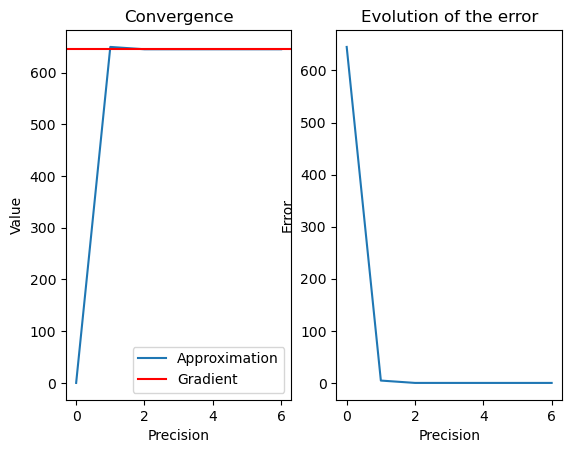

In [29]:
# TEST 1 : given function
func_1 = lambda x : pow(x,3) * 21
value_1 = 3.2
precision_1 = 7

verification(func_1,value_1,precision_1)

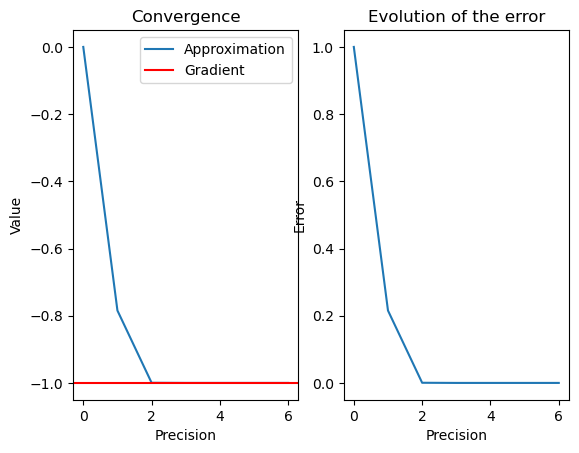

In [30]:
# TEST 2 : f(x) = x^3 - 2.x^2 + 4
func_2 = lambda x : pow(x,3) - pow(x,2) * 2 + 4
value_2 = 1.0
precision_2 = 7

verification(func_2,value_2,precision_2)

*We can see here that the gradient calculated by our previous code seem's to be right. In fact, the quantity that has to converge to the derivative of the function seem's to converge to the gradient calculated.*

*To conclude, there isn't any abnormality with the computation of the gradient, which seem's to be right.*